# HVFHV - Model 1

- Reads existing small CSV outputs only.
- Does not rerun full-data jobs, full parquet reads, or DS_z pipelines.
- Focuses on Model 1 only: whether higher HVFHV zone-direction fee burden is associated with 2025 vs 2024 volume change.
- Model 2 is pending until `data/processed/disruption_score/hvfhv_monthly_panel.csv` exists.

## Setup

Small helpers keep the notebook reproducible and focused on final review rather than data production.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "data" / "processed").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

MODELING = REPO_ROOT / "data" / "processed" / "modeling"
DS = REPO_ROOT / "data" / "processed" / "disruption_score"

PATHS = {
    "features": MODELING / "hvfhv_model1_zone_features.csv",
    "rank_stability": DS / "hvfhv_ds_rank_stability.csv",
    "top_overlap": DS / "hvfhv_ds_top_zone_overlap.csv",
    "borough_corr": DS / "hvfhv_borough_correlation.csv",
    "manhattan_corr": DS / "hvfhv_within_manhattan_correlation.csv",
}


def read_required_csv(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing required input: {path.relative_to(REPO_ROOT)}")
    return pd.read_csv(path)


def corr_pair(df, x, y, method="pearson"):
    d = df[[x, y]].dropna()
    if method == "spearman":
        corr = d[x].rank(method="average").corr(d[y].rank(method="average"), method="pearson")
    else:
        corr = d[x].corr(d[y], method="pearson")
    return pd.Series({"method": method, "n": len(d), "corr": corr})


def pct(x):
    return 100 * x


def display_pct_table(df, pct_cols, decimals=2):
    out = df.copy()
    for col in pct_cols:
        out[col] = pct(out[col])
    return out.round(decimals)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 120})

## Load Inputs And QA

The notebook stops if any expected small CSV input is missing or if the Model 1 feature table no longer has the required columns.

In [2]:
features = read_required_csv(PATHS["features"])
rank_stability = read_required_csv(PATHS["rank_stability"])
top_overlap = read_required_csv(PATHS["top_overlap"])
borough_corr = read_required_csv(PATHS["borough_corr"])
manhattan_corr = read_required_csv(PATHS["manhattan_corr"])

required_columns = [
    "location_id", "direction", "Borough", "zone_name", "service_zone",
    "DS_z", "DS_z_median", "pct_volume_change", "delta_volume",
    "n_trips_2024", "n_trips_2025", "low_n_flag",
    "avg_base_fare_2024", "avg_total_cost_2024", "avg_trip_distance_2024",
    "avg_trip_duration_2024", "log_n_trips_2024", "burden_rank", "DS_z_quartile",
]
missing_columns = sorted(set(required_columns) - set(features.columns))
if missing_columns:
    raise ValueError(f"Feature table is missing required columns: {missing_columns}")

print(f"Feature rows: {len(features):,}")
print(f"Unique zone-direction pairs: {features[['location_id', 'direction']].drop_duplicates().shape[0]:,}")
print(f"Low-N flagged rows: {int(features['low_n_flag'].sum()):,}")
print("\nAllowed input files:")
for name, p in PATHS.items():
    print(f"- {name}: {p.relative_to(REPO_ROOT)}")

missing_required_values = features[required_columns].isna().sum()
missing_required_values[missing_required_values > 0]

Feature rows: 525
Unique zone-direction pairs: 525
Low-N flagged rows: 6

Allowed input files:
- features: data\processed\modeling\hvfhv_model1_zone_features.csv
- rank_stability: data\processed\disruption_score\hvfhv_ds_rank_stability.csv
- top_overlap: data\processed\disruption_score\hvfhv_ds_top_zone_overlap.csv
- borough_corr: data\processed\disruption_score\hvfhv_borough_correlation.csv
- manhattan_corr: data\processed\disruption_score\hvfhv_within_manhattan_correlation.csv


pct_volume_change         1
avg_base_fare_2024        1
avg_total_cost_2024       1
avg_trip_distance_2024    1
avg_trip_duration_2024    1
log_n_trips_2024          1
dtype: int64

## Model 1: DS_z Vs pct_volume_change

Model 1 asks whether higher-burden zone-direction pairs are associated with larger volume changes. This is a descriptive association, not causal proof.

In [3]:
m1 = features[(~features["low_n_flag"].astype(bool)) & features["pct_volume_change"].notna()].copy()

corr_summary = pd.DataFrame([
    corr_pair(m1, "DS_z", "pct_volume_change", "pearson"),
    corr_pair(m1, "DS_z", "pct_volume_change", "spearman"),
    corr_pair(m1, "DS_z_median", "pct_volume_change", "pearson"),
    corr_pair(m1, "DS_z_median", "pct_volume_change", "spearman"),
])
corr_summary["corr"] = corr_summary["corr"].round(3)

print(f"Model 1 usable rows: {len(m1):,} of {len(features):,}")
corr_summary

Model 1 usable rows: 519 of 525


,method,n,corr
0,pearson,519,-0.610
1,spearman,519,-0.643
2,pearson,519,-0.599
3,spearman,519,-0.637


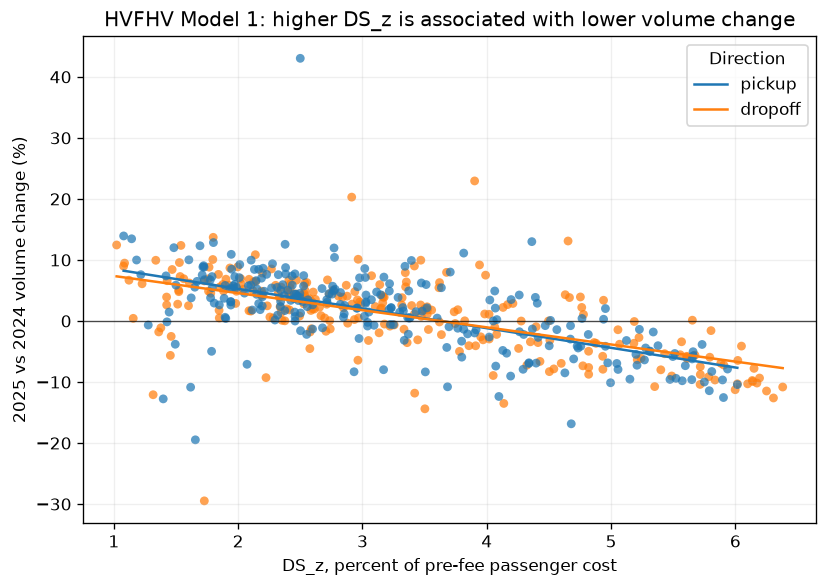

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = np.where(m1["direction"].eq("pickup"), "tab:blue", "tab:orange")
ax.scatter(pct(m1["DS_z"]), pct(m1["pct_volume_change"]), c=colors, alpha=0.72, s=28, linewidths=0)

for direction, color in [("pickup", "tab:blue"), ("dropoff", "tab:orange")]:
    g = m1[m1["direction"].eq(direction)]
    if len(g) >= 2:
        x = pct(g["DS_z"].to_numpy())
        y = pct(g["pct_volume_change"].to_numpy())
        slope, intercept = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, intercept + slope * xs, color=color, linewidth=1.5, label=direction)

ax.axhline(0, color="black", linewidth=0.8, alpha=0.7)
ax.set_title("HVFHV Model 1: higher DS_z is associated with lower volume change")
ax.set_xlabel("DS_z, percent of pre-fee passenger cost")
ax.set_ylabel("2025 vs 2024 volume change (%)")
ax.legend(title="Direction")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Finding.** HVFHV has a clear negative Model 1 association: higher DS_z zone-direction pairs tend to have lower 2025 vs 2024 volume change. This supports a burden-vs-volume descriptive finding, but the cross-zone design still cannot separate fee burden from dense-core geography or other demand shifts.

## Quartiles And Top Burden Zones

Quartiles make the gradient easier to read, while the top-zone table supports the burden-ranking deliverable.

In [5]:
quartile_summary = (
    m1.groupby(["direction", "DS_z_quartile"], observed=True)
    .agg(
        n_pairs=("location_id", "count"),
        avg_DS_z_pct=("DS_z", lambda s: pct(s.mean())),
        avg_volume_change_pct=("pct_volume_change", lambda s: pct(s.mean())),
        median_volume_change_pct=("pct_volume_change", lambda s: pct(s.median())),
    )
    .reset_index()
)
quartile_summary.round(2)

,direction,DS_z_quartile,n_pairs,avg_DS_z_pct,avg_volume_change_pct,median_volume_change_pct
0,dropoff,Q1 lowest,65,1.76,4.41,5.59
1,dropoff,Q2,66,2.64,3.18,3.55
2,dropoff,Q3,64,3.61,1.08,1.63
3,dropoff,Q4 highest,65,5.32,-5.34,-6.15
4,pickup,Q1 lowest,65,1.81,4.65,5.75
5,pickup,Q2,64,2.54,4.63,4.27
6,pickup,Q3,64,3.45,1.20,1.49
7,pickup,Q4 highest,66,4.99,-4.84,-5.16


In [6]:
top_burden = (
    features.sort_values(["direction", "burden_rank"])
    .groupby("direction", group_keys=False)
    .head(10)
    [["burden_rank", "location_id", "direction", "Borough", "zone_name", "DS_z", "pct_volume_change", "n_trips_2024", "n_trips_2025"]]
    .rename(columns={"DS_z": "DS_z_pct", "pct_volume_change": "volume_change_pct"})
)
top_burden = display_pct_table(top_burden, ["DS_z_pct", "volume_change_pct"])
top_burden

,burden_rank,location_id,direction,Borough,zone_name,DS_z_pct,volume_change_pct,n_trips_2024,n_trips_2025
0,1,4,dropoff,Manhattan,Alphabet City,6.38,-10.82,271542.0,242158
1,2,224,dropoff,Manhattan,Stuy Town/Peter Cooper Village,6.31,-12.61,187122.0,163517
2,3,79,dropoff,Manhattan,East Village,6.25,-11.47,1119252.0,990843
3,4,249,dropoff,Manhattan,West Village,6.19,-9.35,824488.0,747373
4,5,114,dropoff,Manhattan,Greenwich Village South,6.17,-10.17,589097.0,529171
5,6,137,dropoff,Manhattan,Kips Bay,6.15,-7.77,552594.0,509670
6,7,232,dropoff,Manhattan,Two Bridges/Seward Park,6.14,-9.93,400060.0,360354
7,8,113,dropoff,Manhattan,Greenwich Village North,6.14,-9.75,549348.0,495763
8,9,107,dropoff,Manhattan,Gramercy,6.10,-10.30,706153.0,633416
9,10,45,dropoff,Manhattan,Chinatown,6.05,-4.12,223679.0,214468


**Finding.** The highest-burden quartile has the weakest volume performance in both pickup and dropoff directions. The top burden zones are concentrated in Manhattan, so the ranking is useful, but the association remains geographically confounded.

## Robustness Diagnostics

These checks support whether the burden ranking is stable and whether the DS_z-volume association is mostly a Manhattan/core geography pattern.

In [7]:
rank_cols = [
    "definition_key", "direction", "n_zone_direction_pairs",
    "spearman_rank_corr_vs_primary", "mean_abs_rank_delta", "max_abs_rank_delta",
]
rank_view = rank_stability[rank_stability["aggregation_method"].eq("mean")][rank_cols].copy()
rank_view.round(4)

,definition_key,direction,n_zone_direction_pairs,spearman_rank_corr_vs_primary,mean_abs_rank_delta,max_abs_rank_delta
0,floor_0_50_mean,all,525,1.0,0.0038,1
1,floor_0_50_mean,dropoff,263,1.0,0.0076,1
2,floor_0_50_mean,pickup,262,1.0,0.0000,0
3,floor_1_00_mean,all,525,1.0,0.0000,0
4,floor_1_00_mean,dropoff,263,1.0,0.0000,0
5,floor_1_00_mean,pickup,262,1.0,0.0000,0
6,floor_2_00_mean,all,525,1.0,0.0152,4
7,floor_2_00_mean,dropoff,263,1.0,0.0000,0
8,floor_2_00_mean,pickup,262,1.0,0.0305,4
9,floor_5_00_mean,all,525,1.0,0.0648,9


In [8]:
overlap_cols = ["definition_key", "direction", "top_n", "overlapping_zone_count", "overlap_share"]
overlap_view = top_overlap[
    top_overlap["aggregation_method"].eq("mean") & top_overlap["top_n"].isin([10, 20])
][overlap_cols].copy()
overlap_view.round(3)

,definition_key,direction,top_n,overlapping_zone_count,overlap_share
0,floor_0_50_mean,dropoff,10,10,1.0
1,floor_0_50_mean,dropoff,20,20,1.0
2,floor_0_50_mean,pickup,10,10,1.0
3,floor_0_50_mean,pickup,20,20,1.0
4,floor_1_00_mean,dropoff,10,10,1.0
5,floor_1_00_mean,dropoff,20,20,1.0
6,floor_1_00_mean,pickup,10,10,1.0
7,floor_1_00_mean,pickup,20,20,1.0
8,floor_2_00_mean,dropoff,10,10,1.0
9,floor_2_00_mean,dropoff,20,20,1.0


In [9]:
borough_view = borough_corr[
    borough_corr["group_type"].isin(["all_zones", "manhattan_split", "direction"])
][["group_type", "group_name", "borough", "direction", "n_rows", "pearson_corr", "spearman_corr", "sufficient_n"]]

manhattan_view = manhattan_corr[
    ["group_type", "group_name", "borough", "direction", "n_rows", "pearson_corr", "spearman_corr", "sufficient_n"]
]

print("Borough and direction diagnostics:")
display(borough_view.round(3))
print("\nManhattan diagnostics:")
display(manhattan_view.round(3))

Borough and direction diagnostics:


,group_type,group_name,borough,direction,n_rows,pearson_corr,spearman_corr,sufficient_n
0,all_zones,all zones,NaN,NaN,524,-0.525,-0.633,True
1,manhattan_split,Manhattan only,Manhattan,NaN,135,-0.540,-0.526,True
2,manhattan_split,non-Manhattan only,NaN,NaN,389,-0.227,-0.350,True
10,direction,dropoff only,NaN,dropoff,262,-0.484,-0.632,True
11,direction,pickup only,NaN,pickup,262,-0.583,-0.633,True



Manhattan diagnostics:


,group_type,group_name,borough,direction,n_rows,pearson_corr,spearman_corr,sufficient_n
0,manhattan_split,Manhattan only,Manhattan,NaN,135,-0.54,-0.526,True
1,borough,Manhattan,Manhattan,NaN,135,-0.54,-0.526,True
2,borough_direction,Manhattan dropoff,Manhattan,dropoff,68,-0.55,-0.524,True
3,borough_direction,Manhattan pickup,Manhattan,pickup,67,-0.56,-0.535,True


**Finding.** The denominator-floor checks show a stable ranking, and top-zone overlap remains high. Borough and Manhattan diagnostics keep the interpretation honest: the association persists in Manhattan, but that does not make it causal because geography and burden are still tightly linked.

## Pre-Policy Control Diagnostics

These are 2024-only controls available in the Model 1 feature table. They are diagnostics for collinearity and confounding, not a causal regression specification.

In [10]:
control_cols = [
    "avg_trip_distance_2024",
    "avg_base_fare_2024",
    "avg_total_cost_2024",
    "avg_trip_duration_2024",
    "log_n_trips_2024",
]
control_summary = m1[control_cols].describe().T[["count", "mean", "std", "min", "50%", "max"]]
control_summary.round(3)

,count,mean,std,min,50%,max
avg_trip_distance_2024,519.0,4.806,1.509,2.382,4.497,18.014
avg_base_fare_2024,519.0,23.383,6.225,12.751,21.749,81.229
avg_total_cost_2024,519.0,27.782,8.341,14.627,25.341,109.547
avg_trip_duration_2024,519.0,1119.311,196.865,540.069,1075.425,2699.336
log_n_trips_2024,519.0,12.331,1.345,5.328,12.595,15.234


In [11]:
collinearity_cols = ["DS_z", "pct_volume_change"] + control_cols
corr_matrix = m1[collinearity_cols].rank(method="average").corr(method="pearson")
corr_matrix.round(3)

,DS_z,pct_volume_change,avg_trip_distance_2024,avg_base_fare_2024,avg_total_cost_2024,avg_trip_duration_2024,log_n_trips_2024
DS_z,1.000,-0.643,-0.366,0.285,0.329,0.443,0.595
pct_volume_change,-0.643,1.000,0.172,-0.387,-0.413,-0.512,-0.448
avg_trip_distance_2024,-0.366,0.172,1.000,0.597,0.572,0.341,-0.387
avg_base_fare_2024,0.285,-0.387,0.597,1.000,0.991,0.860,0.091
avg_total_cost_2024,0.329,-0.413,0.572,0.991,1.000,0.838,0.113
avg_trip_duration_2024,0.443,-0.512,0.341,0.860,0.838,1.000,0.266
log_n_trips_2024,0.595,-0.448,-0.387,0.091,0.113,0.266,1.000


**Finding.** DS_z is correlated with baseline trip economics and baseline volume, so adding controls would not turn Model 1 into a clean causal design. The right interpretation is association plus burden ranking.

## Model 1 Spec Sensitivity: Distance Vs Fare Controls

The team decision was to compare one upstream trip-size control (`avg_trip_distance_2024`) with one fare control (`avg_base_fare_2024`). The OLS table requires `statsmodels`; if it is unavailable, the notebook reports that and skips the spec results rather than fabricating estimates.

In [12]:
spec_corr = pd.DataFrame([
    corr_pair(m1, "DS_z", "avg_trip_distance_2024", "spearman"),
    corr_pair(m1, "DS_z", "avg_base_fare_2024", "spearman"),
    corr_pair(m1, "avg_trip_distance_2024", "avg_base_fare_2024", "spearman"),
])
spec_corr.insert(0, "comparison", [
    "DS_z vs avg_trip_distance_2024",
    "DS_z vs avg_base_fare_2024",
    "avg_trip_distance_2024 vs avg_base_fare_2024",
])
spec_corr[["comparison", "method", "n", "corr"]].round(3)

,comparison,method,n,corr
0,DS_z vs avg_trip_distance_2024,spearman,519,-0.366
1,DS_z vs avg_base_fare_2024,spearman,519,0.285
2,avg_trip_distance_2024 vs avg_base_fare_2024,spearman,519,0.597


In [13]:
try:
    import statsmodels.formula.api as smf
except ImportError:
    spec_results = pd.DataFrame()
    print("statsmodels is not installed in this environment; skipping the OLS spec-sensitivity table.")
else:
    spec_definitions = [
        ("DS_z only", "pct_volume_change ~ DS_z", ["pct_volume_change", "DS_z"]),
        ("DS_z + borough", "pct_volume_change ~ DS_z + C(Borough)", ["pct_volume_change", "DS_z", "Borough"]),
        (
            "DS_z + distance",
            "pct_volume_change ~ DS_z + avg_trip_distance_2024",
            ["pct_volume_change", "DS_z", "avg_trip_distance_2024"],
        ),
        (
            "DS_z + fare",
            "pct_volume_change ~ DS_z + avg_base_fare_2024",
            ["pct_volume_change", "DS_z", "avg_base_fare_2024"],
        ),
        (
            "DS_z + distance + borough",
            "pct_volume_change ~ DS_z + avg_trip_distance_2024 + C(Borough)",
            ["pct_volume_change", "DS_z", "avg_trip_distance_2024", "Borough"],
        ),
        (
            "DS_z + fare + borough",
            "pct_volume_change ~ DS_z + avg_base_fare_2024 + C(Borough)",
            ["pct_volume_change", "DS_z", "avg_base_fare_2024", "Borough"],
        ),
    ]

    rows = []
    for spec_name, formula, cols in spec_definitions:
        d = m1.dropna(subset=cols).copy()
        model = smf.ols(formula, data=d).fit()
        lo, hi = model.conf_int().loc["DS_z"]
        coef = model.params["DS_z"]
        rows.append({
            "spec": spec_name,
            "DS_z_coef": coef,
            "std_error": model.bse["DS_z"],
            "ci_low": lo,
            "ci_high": hi,
            "sign": "negative" if coef < 0 else "positive" if coef > 0 else "zero",
            "n_obs": int(model.nobs),
        })

    spec_results = pd.DataFrame(rows)
    display(spec_results.round({"DS_z_coef": 3, "std_error": 3, "ci_low": 3, "ci_high": 3}))

    distance_specs = spec_results[spec_results["spec"].str.contains("distance", case=False)]
    fare_specs = spec_results[spec_results["spec"].str.contains("fare", case=False)]
    same_sign = bool(set(distance_specs["sign"]) == set(fare_specs["sign"]) and len(set(distance_specs["sign"])) == 1)
    if same_sign:
        print("Distance and fare controls give the same qualitative DS_z sign. Prefer distance as the cleaner primary control.")
    else:
        print("Distance and fare controls differ qualitatively. This reinforces Model 1 non-identification and collinearity risk.")

,spec,DS_z_coef,std_error,ci_low,ci_high,sign,n_obs
0,DS_z only,-2.996,0.171,-3.332,-2.659,negative,519
1,DS_z + borough,-1.375,0.273,-1.910,-0.839,negative,519
2,DS_z + distance,-3.253,0.178,-3.602,-2.903,negative,519
3,DS_z + fare,-2.855,0.169,-3.187,-2.522,negative,519
4,DS_z + distance + borough,-1.805,0.292,-2.379,-1.231,negative,519
5,DS_z + fare + borough,-1.472,0.271,-2.004,-0.941,negative,519


Distance and fare controls give the same qualitative DS_z sign. Prefer distance as the cleaner primary control.


**Finding.** The spec sensitivity points the same way across distance-control and fare-control versions: the DS_z coefficient stays negative in all six OLS variants. The distance and fare controls therefore do not materially change the qualitative Model 1 conclusion. Prefer distance as the cleaner primary control because it is more upstream and less mechanically tied to DS_z. This remains a sensitivity check, not final causal identification; the result is an association, not proof of a causal effect on volume change.

## Model 2 Status

HVFHV Model 2 is not implemented in this notebook.

Missing required artifact:

```text
data/processed/disruption_score/hvfhv_monthly_panel.csv
```

Expected schema:

```text
zone, direction, year, month, n_trips, Borough, zone_name, crz_zone, charged_share_2024_geo
```

The exposure measure should be geography-based and pre-policy, not a 2025 outcome. It should be validated against 2025 observed `charged_cbd_flag` before estimating an exposure-gradient DiD. Until that panel exists, this notebook should not report Model 2 estimates.

## Final Summary

- Model 1 evidence exists: higher HVFHV DS_z is associated with lower 2025 vs 2024 zone-direction volume change.
- The burden ranking and top-zone lists are supported by stable denominator-floor and top-overlap diagnostics.
- Pre-policy control diagnostics show meaningful collinearity, so Model 1 remains descriptive/inferential rather than causal proof.
- Model 2 is pending until `data/processed/disruption_score/hvfhv_monthly_panel.csv` exists with geography-based `charged_share_2024_geo`.
- Model 3 is postponed and should not be added here.